Импортируем библиотеки

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

# 1. Текстовое описание набора данных


В качестве исследуемого датасета выбран датасет характеристик различных боеприпасов из компьютерной игры Escape from Tarkov, найденный на ресурсе kaggle.


 https://www.kaggle.com/datasets/jamesloh/escape-from-tarkov-ammo-dataset?resource=download

 Исходный файл представлен в формате csv.

 Колонки:

*   name - полное название боеприпаса, число в скобках отвечает за количество дробинок/пуль
*   flea - доступность боеприпаса к покупке на барахолке (yes/no)
*   caliber - калибр боеприпаса
*   damage - максимальный урон по незащищенной части тела
*   penetration - значение бронепробития
*   armor_damage - процент урона по броне (%)
*   accuracy - модификатор точности (%)
*   recoil - модификатор отдачи
*   frag_chance - шанс фрагментации за каждое попадание (%)
*   bleed_lt - шанс открытия легкого кровотечения за каждое попадание (%)
*   bleed_hvy - шанс открытия тяжелого кровотечения за каждое попадание (%)
*   b_effectiveness_c1-c6 - Эффективность боеприпаса в зависимости от класса брони  (Класс 1-6)


In [2]:
data = pd.read_csv('tarkov_ammo.csv')

# 2. Основные характеристики датасета



In [3]:
#Первые 5 строк датасета
data.head()

,name,flea,caliber,damage,penetration,armor_damage,accuracy,recoil,frag_chance,bleed_lt,bleed_hvy,b_effectiveness_c1,b_effectiveness_c2,b_effectiveness_c3,b_effectiveness_c4,b_effectiveness_c5,b_effectiveness_c6
0,12/70 5.25mm buckshot (8),yes,12x70mm,37,1,15,0,0,0,0,0,3,3,3,3,3,3
1,12/70 8.5mm Magnum buckshot (8),yes,12x70mm,50,2,26,-15,115,0,20,10,3,3,3,3,3,3
2,12/70 6.5mm Express buckshot (9),yes,12x70mm,35,3,26,15,0,0,0,0,3,3,3,3,3,3
3,12/70 7mm buckshot (8),yes,12x70mm,39,3,26,0,0,0,0,0,3,3,3,3,3,3
4,12/70 Piranha (10),yes,12x70mm,25,24,22,-5,0,0,15,15,6,6,5,4,4,4


In [4]:
print('Всего строк: {}'.format(data.shape[0]))
print('Всего колонок: {}'.format(data.shape[1]))
print('Список колонок: \n{}'.format(data.dtypes))


Всего строк: 164
Всего колонок: 17
Список колонок: 
name                    str
flea                    str
caliber                 str
damage                int64
penetration           int64
armor_damage          int64
accuracy              int64
recoil                int64
frag_chance           int64
bleed_lt              int64
bleed_hvy             int64
b_effectiveness_c1    int64
b_effectiveness_c2    int64
b_effectiveness_c3    int64
b_effectiveness_c4    int64
b_effectiveness_c5    int64
b_effectiveness_c6    int64
dtype: object


In [ ]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

name - 0
flea - 0
caliber - 0
damage - 0
penetration - 0
armor_damage - 0
accuracy - 0
recoil - 0
frag_chance - 0
bleed_lt - 0
bleed_hvy - 0
b_effectiveness_c1 - 0
b_effectiveness_c2 - 0
b_effectiveness_c3 - 0
b_effectiveness_c4 - 0
b_effectiveness_c5 - 0
b_effectiveness_c6 - 0


In [ ]:
# Основные статистические характеристки набора данных
data.describe()

,damage,penetration,armor_damage,accuracy,recoil,frag_chance,bleed_lt,bleed_hvy,b_effectiveness_c1,b_effectiveness_c2,b_effectiveness_c3,b_effectiveness_c4,b_effectiveness_c5,b_effectiveness_c6
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,79.280488,24.597561,41.445122,11.420732,1.993902,23.957317,6.853659,6.731707,5.146341,4.128049,3.085366,2.310976,1.829268,1.457317
std,45.688536,18.488836,22.025711,34.306447,13.654590,22.341837,12.241057,11.172434,1.851028,2.344961,2.577397,2.480773,2.217083,1.988774
min,0.000000,0.000000,0.000000,-28.000000,-30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.000000,11.000000,26.000000,0.000000,0.000000,10.000000,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,65.000000,20.000000,37.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,6.000000,3.000000,1.000000,0.000000,0.000000
75%,87.250000,37.000000,57.000000,5.500000,5.000000,33.000000,15.000000,10.000000,6.000000,6.000000,6.000000,5.000000,4.000000,3.000000
max,265.000000,88.000000,95.000000,170.000000,115.000000,100.000000,80.000000,55.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000


# 3. Визуальное исследование датасета

<Axes: xlabel='damage', ylabel='penetration'>

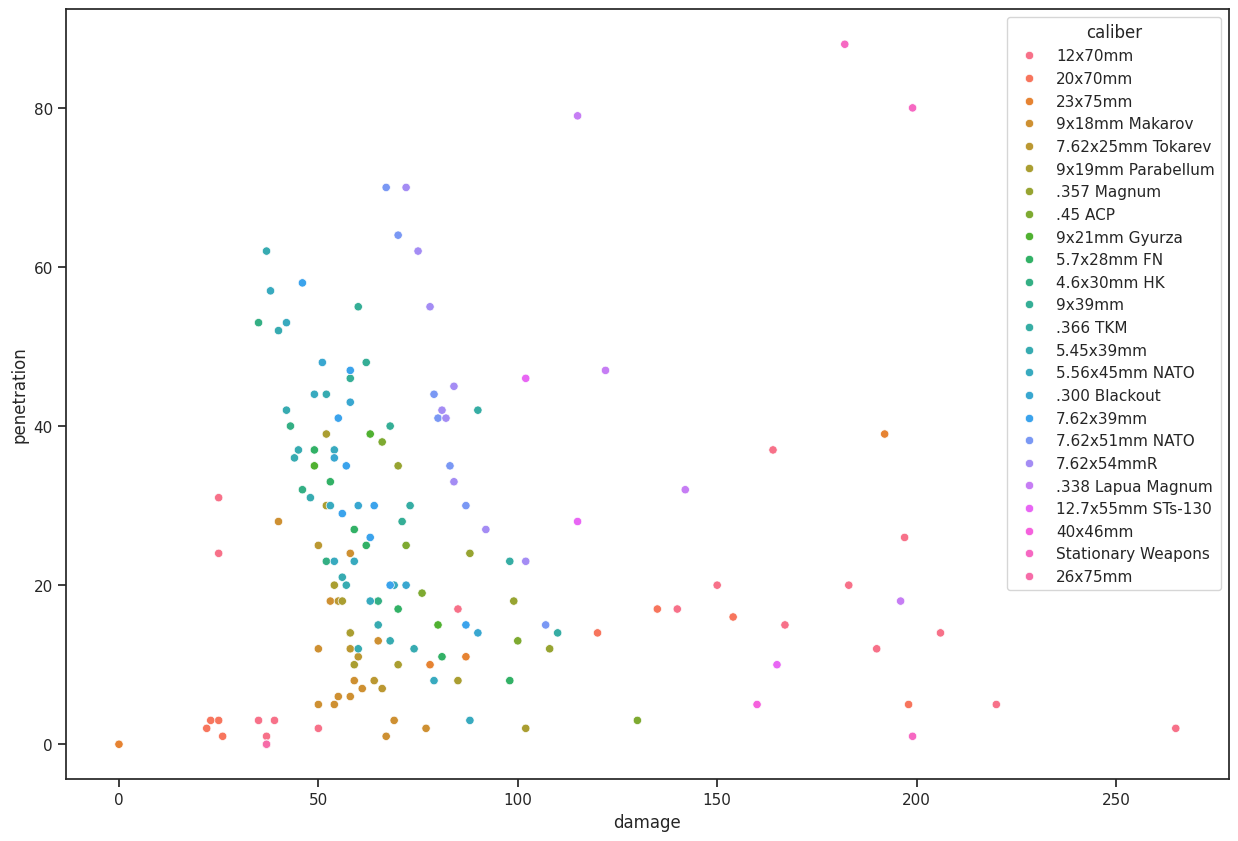

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(ax=ax, x='damage', y='penetration', data=data, hue='caliber')

Сразу стоит заметить, что патроны разных калибров предназначены для разного вида оружия и разных задач, поэтому если сравнивать урон и бронепробитие сразу для всех калибров, мы хоть и увидим, что увеличение урона приводит к уменьшению значений бронепробития, но конкретный коэффициент мы не вычислим, к тому же будут попадаться аналогичные патроны разных калибров, где один будет во всем лучше другого. Поэтому сразу распределим значения по калибрам (отметим точно разными цветами).

Конкретно на данной диаграмме рассеяния сложно рассмотреть какие-либо зависимости, так как точки характеристик различных калибр сливаются между собой. Поэтому соединим прямыми линиями рядом расположенные точки одинакового калибра.

<Axes: xlabel='damage', ylabel='penetration'>

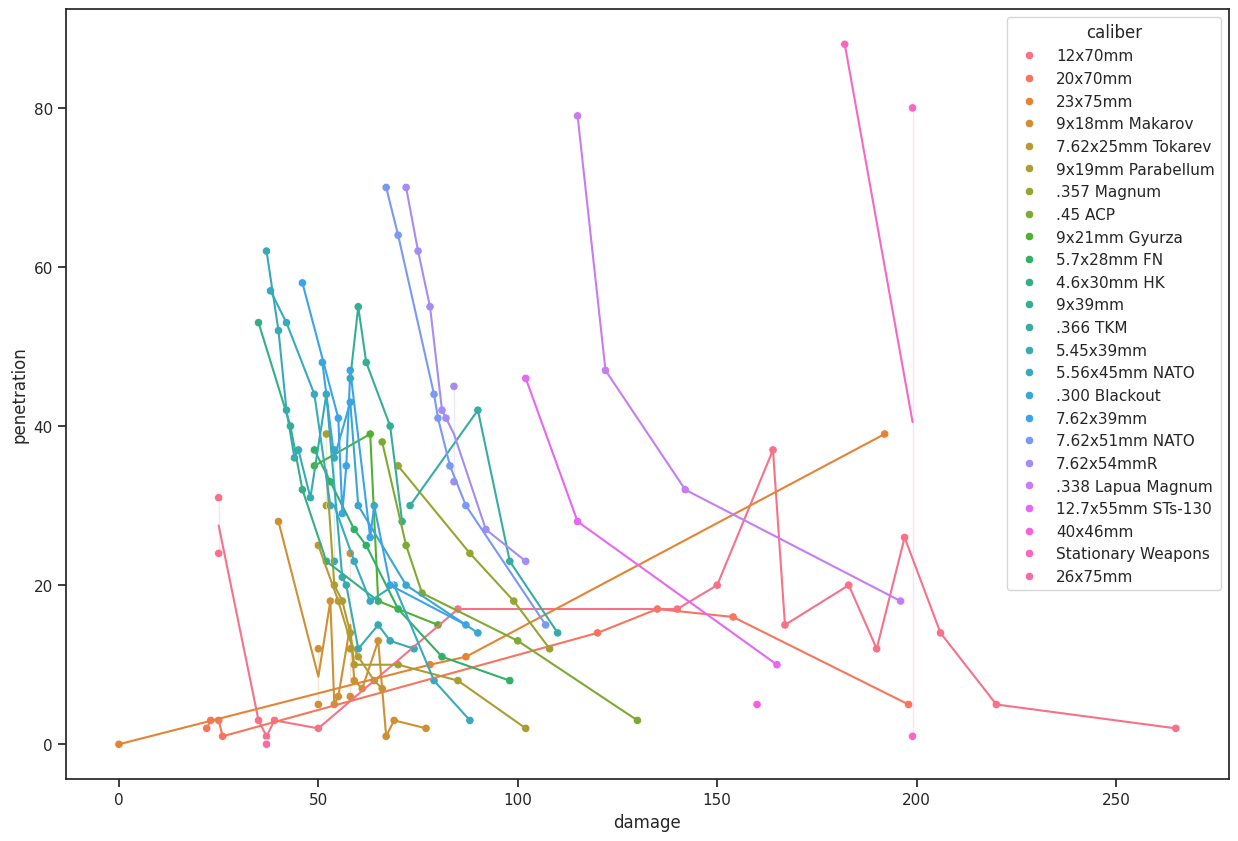

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))

sns.scatterplot(
    ax=ax,
    x='damage',
    y='penetration',
    hue='caliber',
    data=data
)

sns.lineplot(
    ax=ax,
    x='damage',
    y='penetration',
    hue='caliber',
    data=data,
    legend=False
)

На данной диаграмме видно, что большинство калибров имеют обратную зависимость урона от силы бронепробития: чем больше бронепробитие, тем меньше урон.

In [68]:
caliber_tables = dict(tuple(data.groupby('caliber')))
print(caliber_tables.keys())  # список всех калибров
len(caliber_tables.keys())

dict_keys(['.300 Blackout', '.338 Lapua Magnum', '.357 Magnum', '.366 TKM', '.45 ACP', '12.7x55mm STs-130', '12x70mm', '20x70mm', '23x75mm', '26x75mm', '4.6x30mm HK', '40x46mm', '5.45x39mm', '5.56x45mm NATO', '5.7x28mm FN', '7.62x25mm Tokarev', '7.62x39mm', '7.62x51mm NATO', '7.62x54mmR', '9x18mm Makarov', '9x19mm Parabellum', '9x21mm Gyurza', '9x39mm', 'Stationary Weapons'])


24

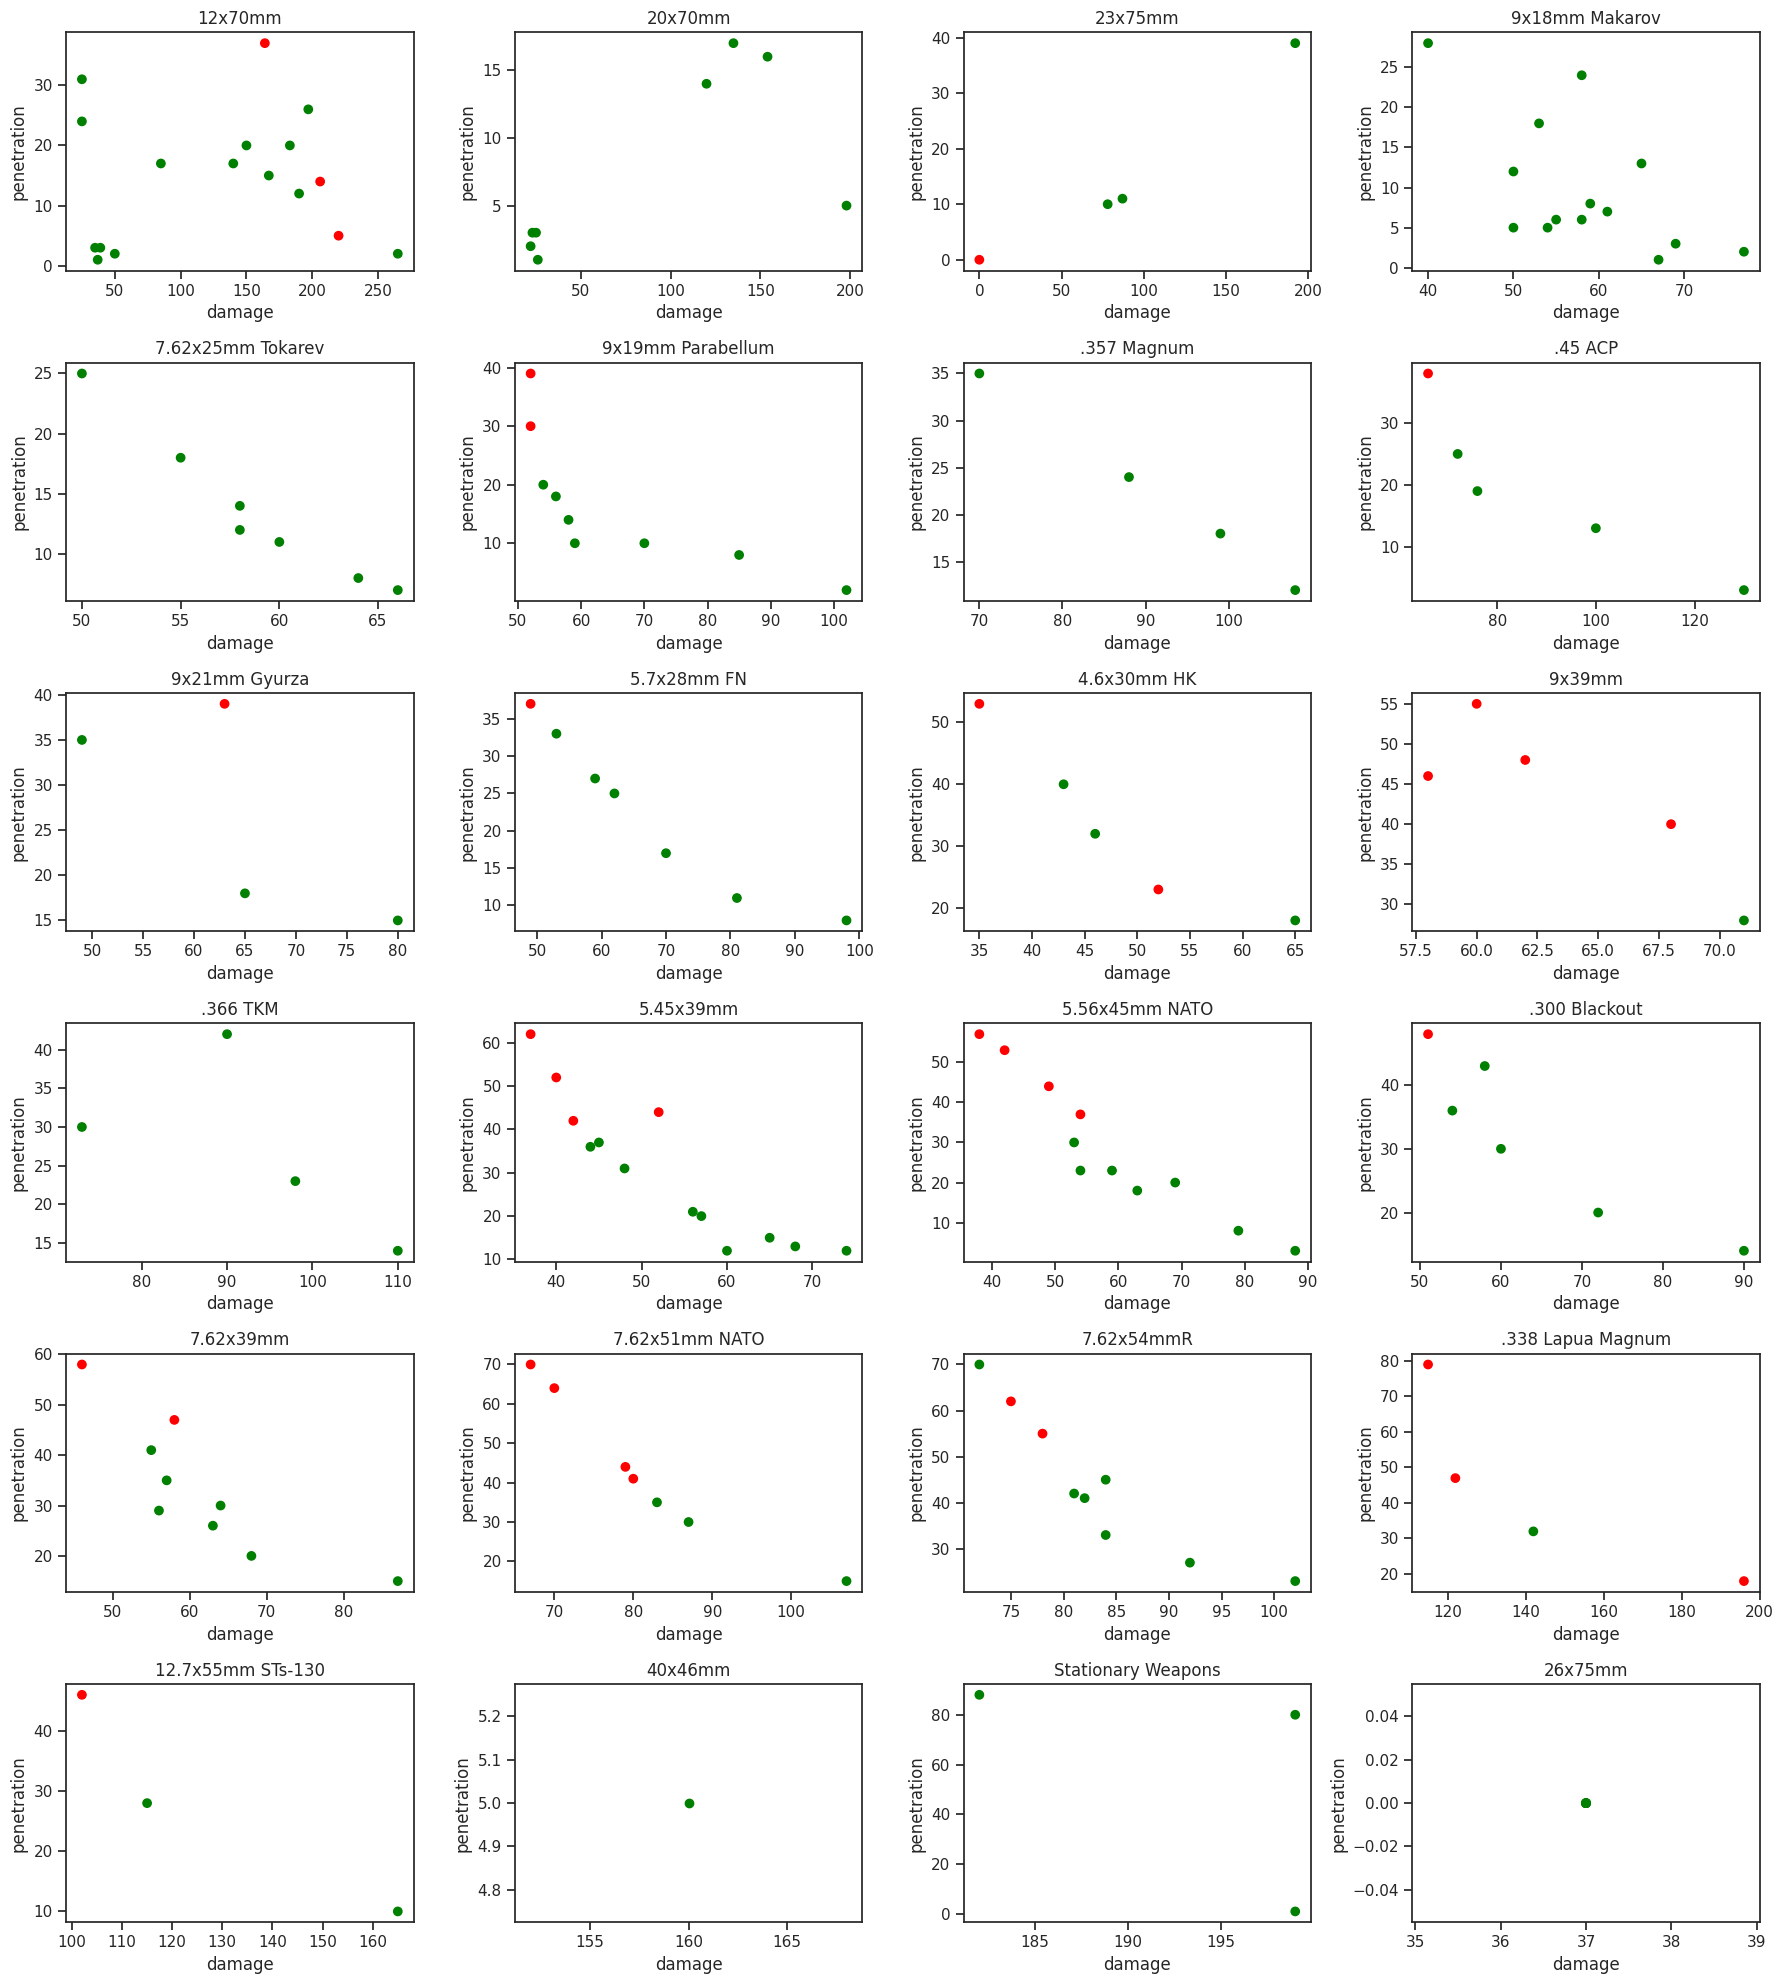

In [66]:
calibers = data['caliber'].unique()

fig, axes = plt.subplots(6, 4, figsize=(18,20))
axes = axes.flatten()


for i, caliber in enumerate(calibers):

    subset = data[data['caliber'] == caliber]
    colors = subset['flea'].map(lambda x: 'green' if x=='yes' else 'red')

    axes[i].scatter(subset['damage'], subset['penetration'], color=colors)
    axes[i].set_title(caliber)
    axes[i].set_xlabel("damage")
    axes[i].set_ylabel("penetration")


plt.tight_layout()
plt.show()

Теперь мы видим, что исключениями в правиле обратной зависимости урон-бронепробитие являются лишь три калибра: 12x70, 20x70, 23x75. На деле все эти боеприпасы являются картечью, а количество дробинок в одном патроне не учтено при составлении датасета. 

Также на диаграммах отлично видно, что у боеприпасов, не доступных к покупке на барахолке (отмечены красными точками), одна из характеристик является очень высокой, что влияет на цену и доступность. Патроны с высоким пробитие (бронепробивающие), и особо высоким уроном (экспансивные) высоко ценятся среди игроков, поэтому не доступны для прямой торговли. Патроны со средними характеристиками в пределах своего калибра не считаются особо ценными, поэтому свободно продаются (отмечены зелеными точками).

/tmp/ipykernel_861/217215251.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['penetration'])


(0.0, 114.40162386204621)

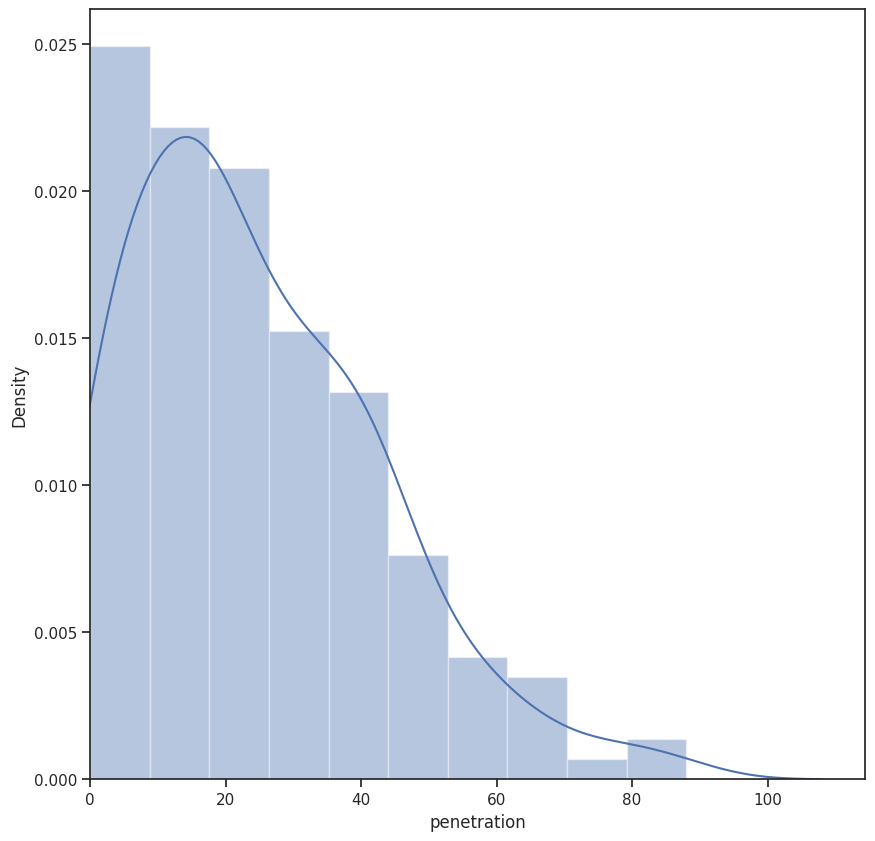

In [42]:
fig, ax = plt.subplots(figsize=(10,10))
sns.distplot(data['penetration'])
ax.set_xlim(left=0)

На гистограмме бронепробития (позволяет оценить плотность вероятности распределения данных) мы можем заметить, что в основном бронепробитие принимает значения в районе 10-30 единиц.

Постепенное убывание количества боеприпасов наблюдается при увеличении значений бронепробития вплоть до 70 единиц. Выше этого значения есть несколько боеприпасов для станкового оружия, их нельзя сравнивать с экземплярами для ручного оружия.

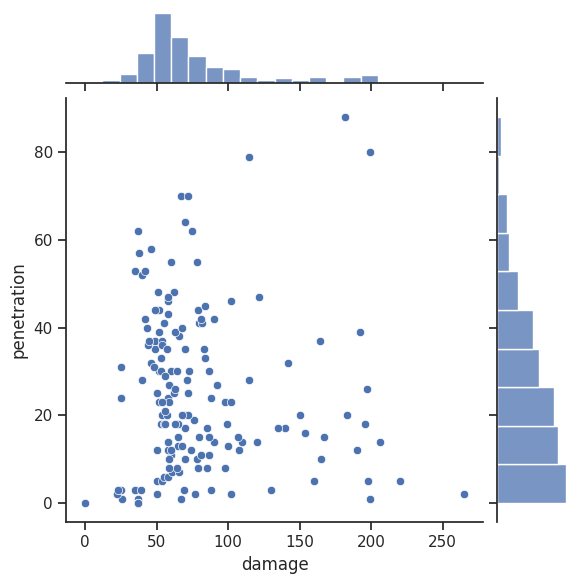

In [43]:
sns.jointplot(x='damage', y='penetration', data=data)

Комбинация гистограмм и диаграмм рассеивания для урона и бронепробития. Мы видим что в Escape From Tarkov более распространены патроны с уроном 50-80 и бронепробитием от 10 до 40.

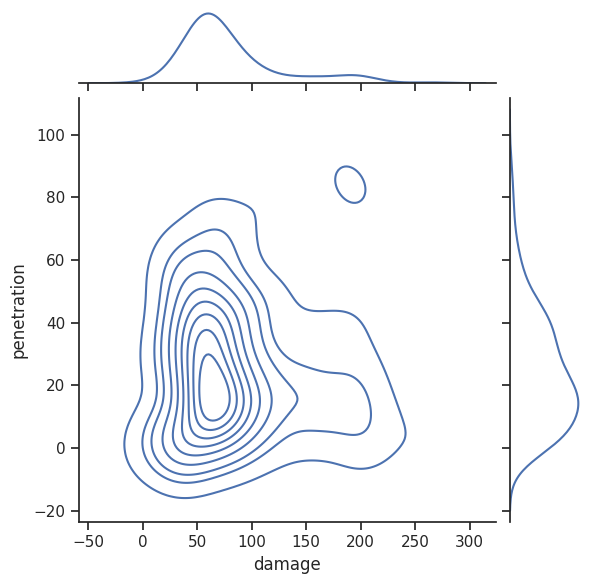

In [44]:
sns.jointplot(x='damage', y='penetration', data=data, kind="kde")

В данном режиме отображения этот вывод более заметен.

Выводим комбинацию гистограмм и диаграмм рассеивания для набора данных урона по телу, по броне и бронепробития. Остальные характеристики будут коррелироваться меньше, их сравнивать не будем. 

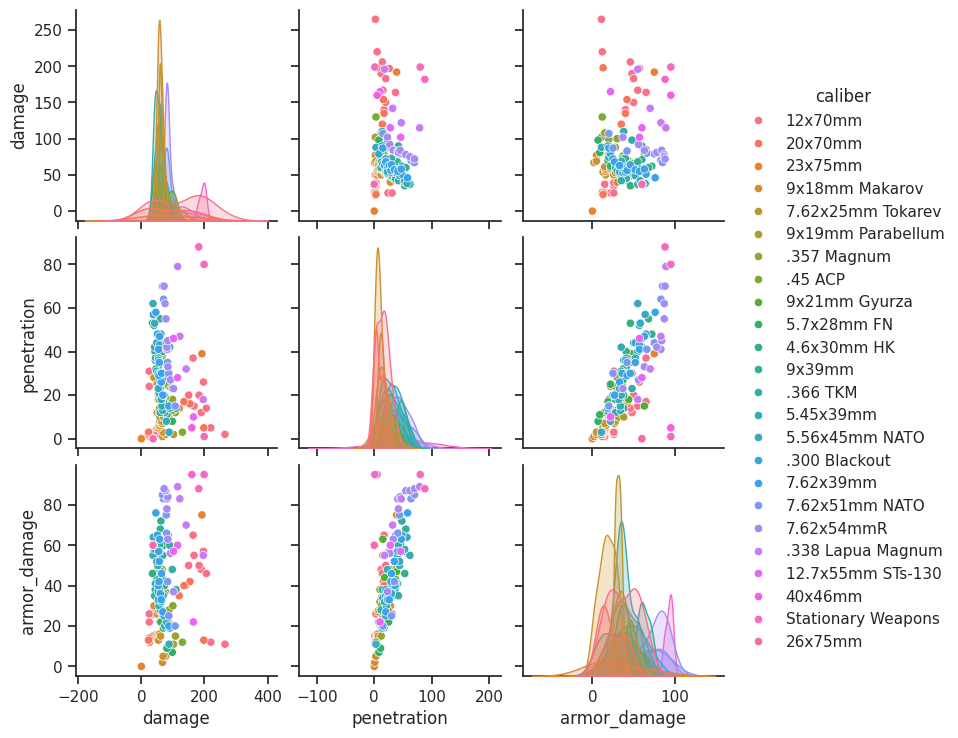

In [46]:
sns.pairplot(
    data,
    vars=['damage', 'penetration', 'armor_damage'],
    hue='caliber'
)

Видим, что при увеличении бронепробития увеличивается и урон по броне.

Связь уроном между значениями по броне и по телу очень слабая.

В очередной раз заметим, что бронепробитие и урон по телу имеют между собой связь в виде обратной зависимости.

<Axes: xlabel='flea', ylabel='damage'>

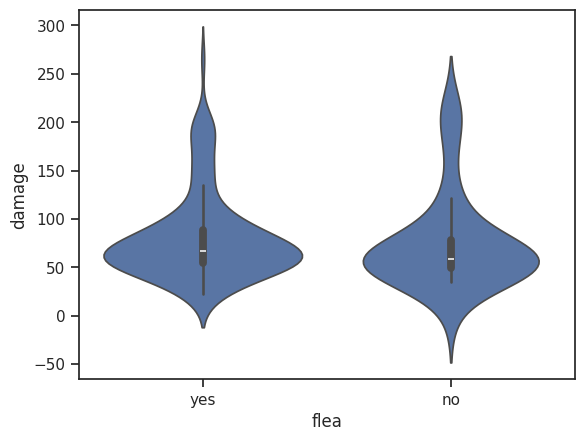

In [ ]:
sns.violinplot(y='damage',x='flea',data=data)

<Axes: xlabel='flea', ylabel='penetration'>

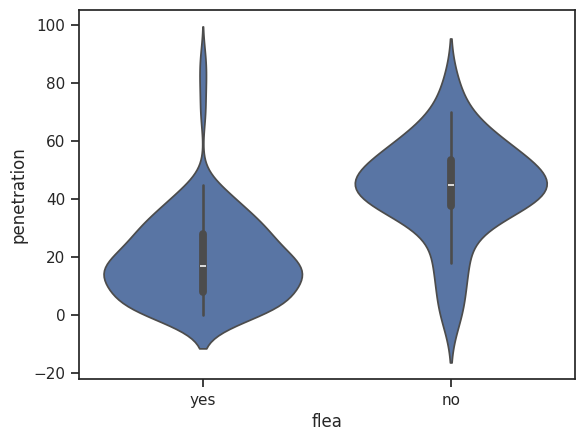

In [56]:
sns.violinplot(y='penetration',x='flea',data=data)

На этих диаграммах с распределением плотности видим, что урон боеприпасов, доступных и недоступных к продаже на барахолке практически не меняется. Однако распределение плотности бронепробития меняется очень сильно, среднее значение повышается примерно на 25 очков.

Из этого можем сделать вывод, что в игре гораздо больше ценится бронепробитие, чем урон.

# 4. Информация о корреляции признаков

Посмотрим, какие нецелевые признаки линейно зависимы между собой.

In [51]:
data[['damage', 'penetration', 'armor_damage','frag_chance','bleed_lt','bleed_hvy']].corr()

,damage,penetration,armor_damage,frag_chance,bleed_lt,bleed_hvy
damage,1.000000,-0.016054,0.198302,0.316543,0.404299,0.498876
penetration,-0.016054,1.000000,0.707253,-0.237317,-0.220724,-0.065034
armor_damage,0.198302,0.707253,1.000000,-0.403881,-0.214671,-0.050395
frag_chance,0.316543,-0.237317,-0.403881,1.000000,0.505333,0.396470
bleed_lt,0.404299,-0.220724,-0.214671,0.505333,1.000000,0.766300
bleed_hvy,0.498876,-0.065034,-0.050395,0.396470,0.766300,1.000000


<Axes: >

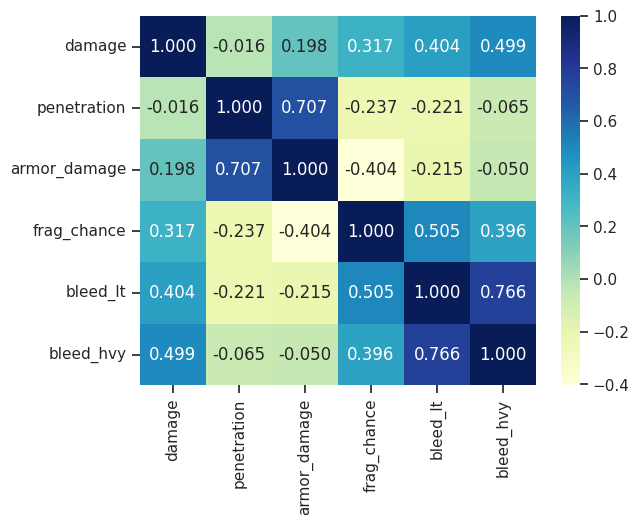

In [53]:
sns.heatmap(data[['damage', 'penetration', 'armor_damage','frag_chance','bleed_lt','bleed_hvy']].corr(), cmap='YlGnBu', annot=True, fmt='.3f')

Дополнительно к выводам, полученным в Пункте 3, заметим:
1. Существует высокая связь между шансами нанесения слабого и сильного кровотечения (0.76).
2. Шанс на фрагментацию сильнее коррелирует с шансом на слабое кровотечение (0.51), чем с шансом на сильное (0.4).
3. Существует обратная корреляция между уроном по броне и шансом на фрагментацию (-0.4). Это логично, ведь для фрагментации снаряда внутри тела требуется чтобы снаряд прошел насквозь брони (не сильно повредил).


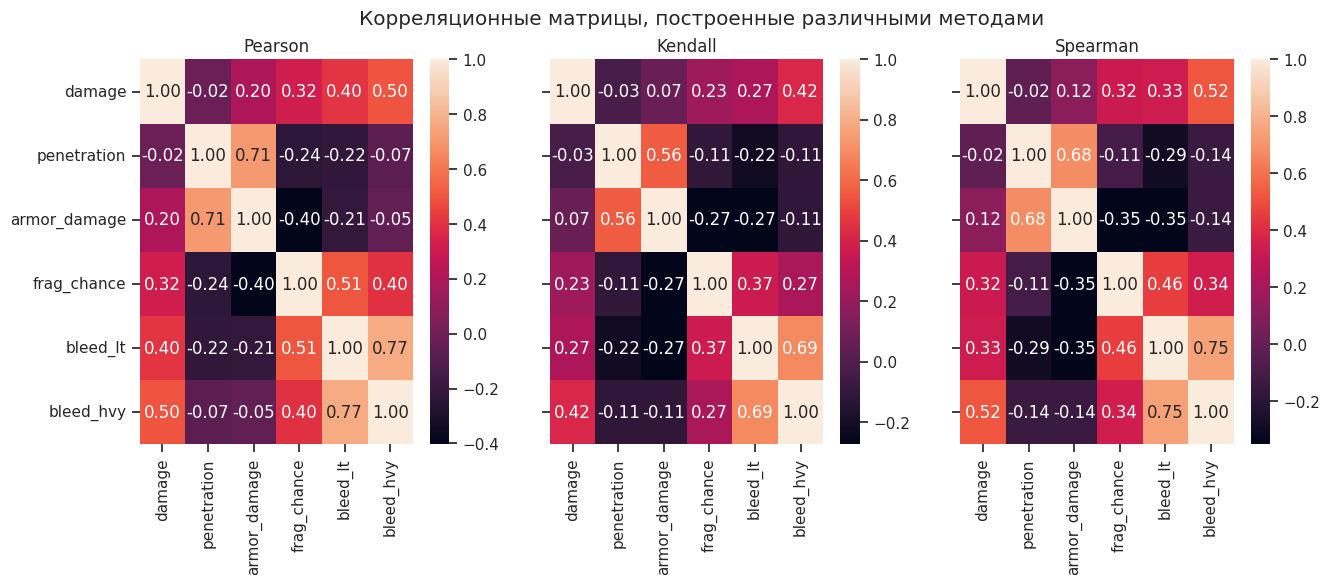

In [54]:
data2=data[['damage', 'penetration', 'armor_damage','frag_chance','bleed_lt','bleed_hvy']]
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(data2.corr(method='pearson'), ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(data2.corr(method='kendall'), ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(data2.corr(method='spearman'), ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')

Корреляционные матрицы, полученные различными методами слабо отличаются друг от друга.